<a href="https://colab.research.google.com/github/yassemine-al/Projet_IA_Parking/blob/main/Entrainement_YOLOv8_Parking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.7 MB/s eta 0:00:00


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="CwtUp1R3u4S4lGc0VWgI")
project = rf.workspace("salims-workspace-ffo1k").project("bdd100k-3zgda-3b0pi")
version = project.version(2)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 144.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to BDD100k-2 in yolov8:: 100%|██████████| 19886/19886 [00:05<00:00, 3648.14it/s] 


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from ultralytics import YOLO
from google.colab import files


model = YOLO('yolov8n.pt')

print("🚀 Lancement de l'entraînement sur TES propres images labellisées...")


results = model.train(
    data='/content/BDD100k-2/data.yaml',
    epochs=20,
    imgsz=640,
    batch=16,
    project='Projet_IA_Conduite',
    name='yolo_nano_perso'
)

print("✅ Entraînement terminé ! Préparation du téléchargement...")


# Corrected path to the best.pt file
chemin_du_modele = '/content/runs/detect/Projet_IA_Conduite/yolo_nano_perso/weights/best.pt'
files.download(chemin_du_modele)

🚀 Lancement de l'entraînement sur TES propres images labellisées...
Ultralytics 8.4.35 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/BDD100k-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_nano_perso, nbs=64, nms=False, opset=None,

FileNotFoundError: Cannot find file: /content/Projet_IA_Conduite/yolo_nano_perso/weights/best.pt

In [ ]:
from google.colab import files

chemin_du_modele = '/content/runs/detect/Projet_IA_Conduite/yolo_nano_perso/weights/best.pt'


files.download(chemin_du_modele)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO
from google.colab import files

# 1. On charge cette fois le modèle "Small" (yolov8s.pt)
model_s = YOLO('yolov8s.pt')

print("🚀 Lancement de l'entraînement avec YOLOv8 Small...")

# 2. On lance l'entraînement avec TES données
results_s = model_s.train(
    data='/content/BDD100k-2/data.yaml', # On garde exactement ton dataset
    epochs=20,                           # On garde 20 epochs pour que la comparaison soit juste
    imgsz=640,
    batch=16,
    project='Projet_IA_Conduite',
    name='yolo_small_perso'              # ⚠️ NOUVEAU DOSSIER : Très important pour ne pas effacer l'autre !
)

print("✅ Entraînement YOLOv8s terminé ! Préparation du téléchargement...")

# 3. On télécharge automatiquement le nouveau modèle
chemin_du_modele_small = '/content/runs/detect/Projet_IA_Conduite/yolo_small_perso/weights/best.pt'
files.download(chemin_du_modele_small)

🚀 Lancement de l'entraînement avec YOLOv8 Small...
Ultralytics 8.4.35 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/BDD100k-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_small_perso, nbs=64, nms=False, opset=None, optimize=False,

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


image 1/1 /content/sample_data/test.jpg: 448x640 6 Voituress, 3 motos, 1 pietons, 44.0ms
Speed: 11.3ms preprocess, 44.0ms inference, 40.1ms postprocess per image at shape (1, 3, 448, 640)
📊 Résultat avec TON modèle importé :


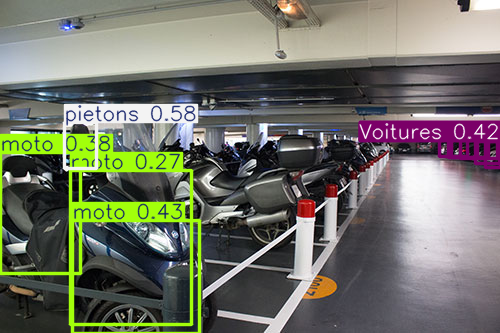

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
from ultralytics import YOLO

# 1. On donne le VRAI chemin (dans le dossier sample_data !)
chemin_small = '/content/sample_data/best.pt'
model_small = YOLO(chemin_small)

# 2. Test avec ton image (elle aussi est dans sample_data)
results = model_small('/content/sample_data/test.jpg', conf=0.25)

# 3. Affichage
image_small = results[0].plot()
print("📊 Résultat avec TON modèle importé :")
cv2_imshow(image_small)

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="CwtUp1R3u4S4lGc0VWgI")
project = rf.workspace("salims-workspace-ffo1k").project("bdd100k-3zgda-3b0pi")
version = project.version(4)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 90.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to BDD100k-4 in yolov8:: 100%|██████████| 405/405 [00:00<00:00, 4655.87it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [8]:
from ultralytics import YOLO
from google.colab import files

print("🚀 Lancement de l'entraînement du Modèle 1 (YOLOv8 Nano)...")

# 1. On charge le modèle Nano (le plus rapide)
model = YOLO('yolov8n.pt')

# 2. On lance l'entraînement avec la MÊME configuration que ton YOLOv8s
results = model.train(
    data='/content/BDD100k-4/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    project='Projet_IA_Conduite',
    name='yolo_nano_perso'
)

print("✅ Entraînement YOLOv8n terminé ! Téléchargement  (best.pt)...")

# 3. Téléchargement direct du meilleur fichier de poids
chemin_du_modele = '/content/runs/detect/Projet_IA_Conduite/yolo_nano_perso/weights/best.pt'
files.download(chemin_du_modele)

🚀 Lancement de l'entraînement du Modèle 1 (YOLOv8 Nano)...
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/BDD100k-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_nano_perso2, nbs=64, nms=False, opset=N

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
from ultralytics import YOLO
from google.colab import files

print(" Lancement de l'entraînement OPTIMAL (50 Epochs) avec YOLOv8 Small (Modèle 2)...")

# 1. On charge cette fois le modèle Small (plus gros, potentiellement plus précis)
model = YOLO('yolov8s.pt')

# 2. On lance l'entraînement avec les MÊMES paramètres
results = model.train(
    data='/content/BDD100k-4/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    project='Projet_IA_Conduite',
    name='yolo_small_50_epochs'
)

print("✅ Entraînement YOLOv8s terminé ! Préparation du téléchargement du cerveau...")

# 3. Téléchargement automatique du meilleur fichier de poids du Small
chemin_du_modele_small = '/content/runs/detect/Projet_IA_Conduite/yolo_small_50_epochs/weights/best.pt'
files.download(chemin_du_modele_small)

 Lancement de l'entraînement OPTIMAL (50 Epochs) avec YOLOv8 Small (Modèle 2)...
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/BDD100k-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_small_50_epochs, 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🟢 COMPARAISON FINALE - MODÈLE 1 : YOLOv8 Nano (50 Epochs)

📊 Courbes d'apprentissage (mAP, Précision, Rappel) :


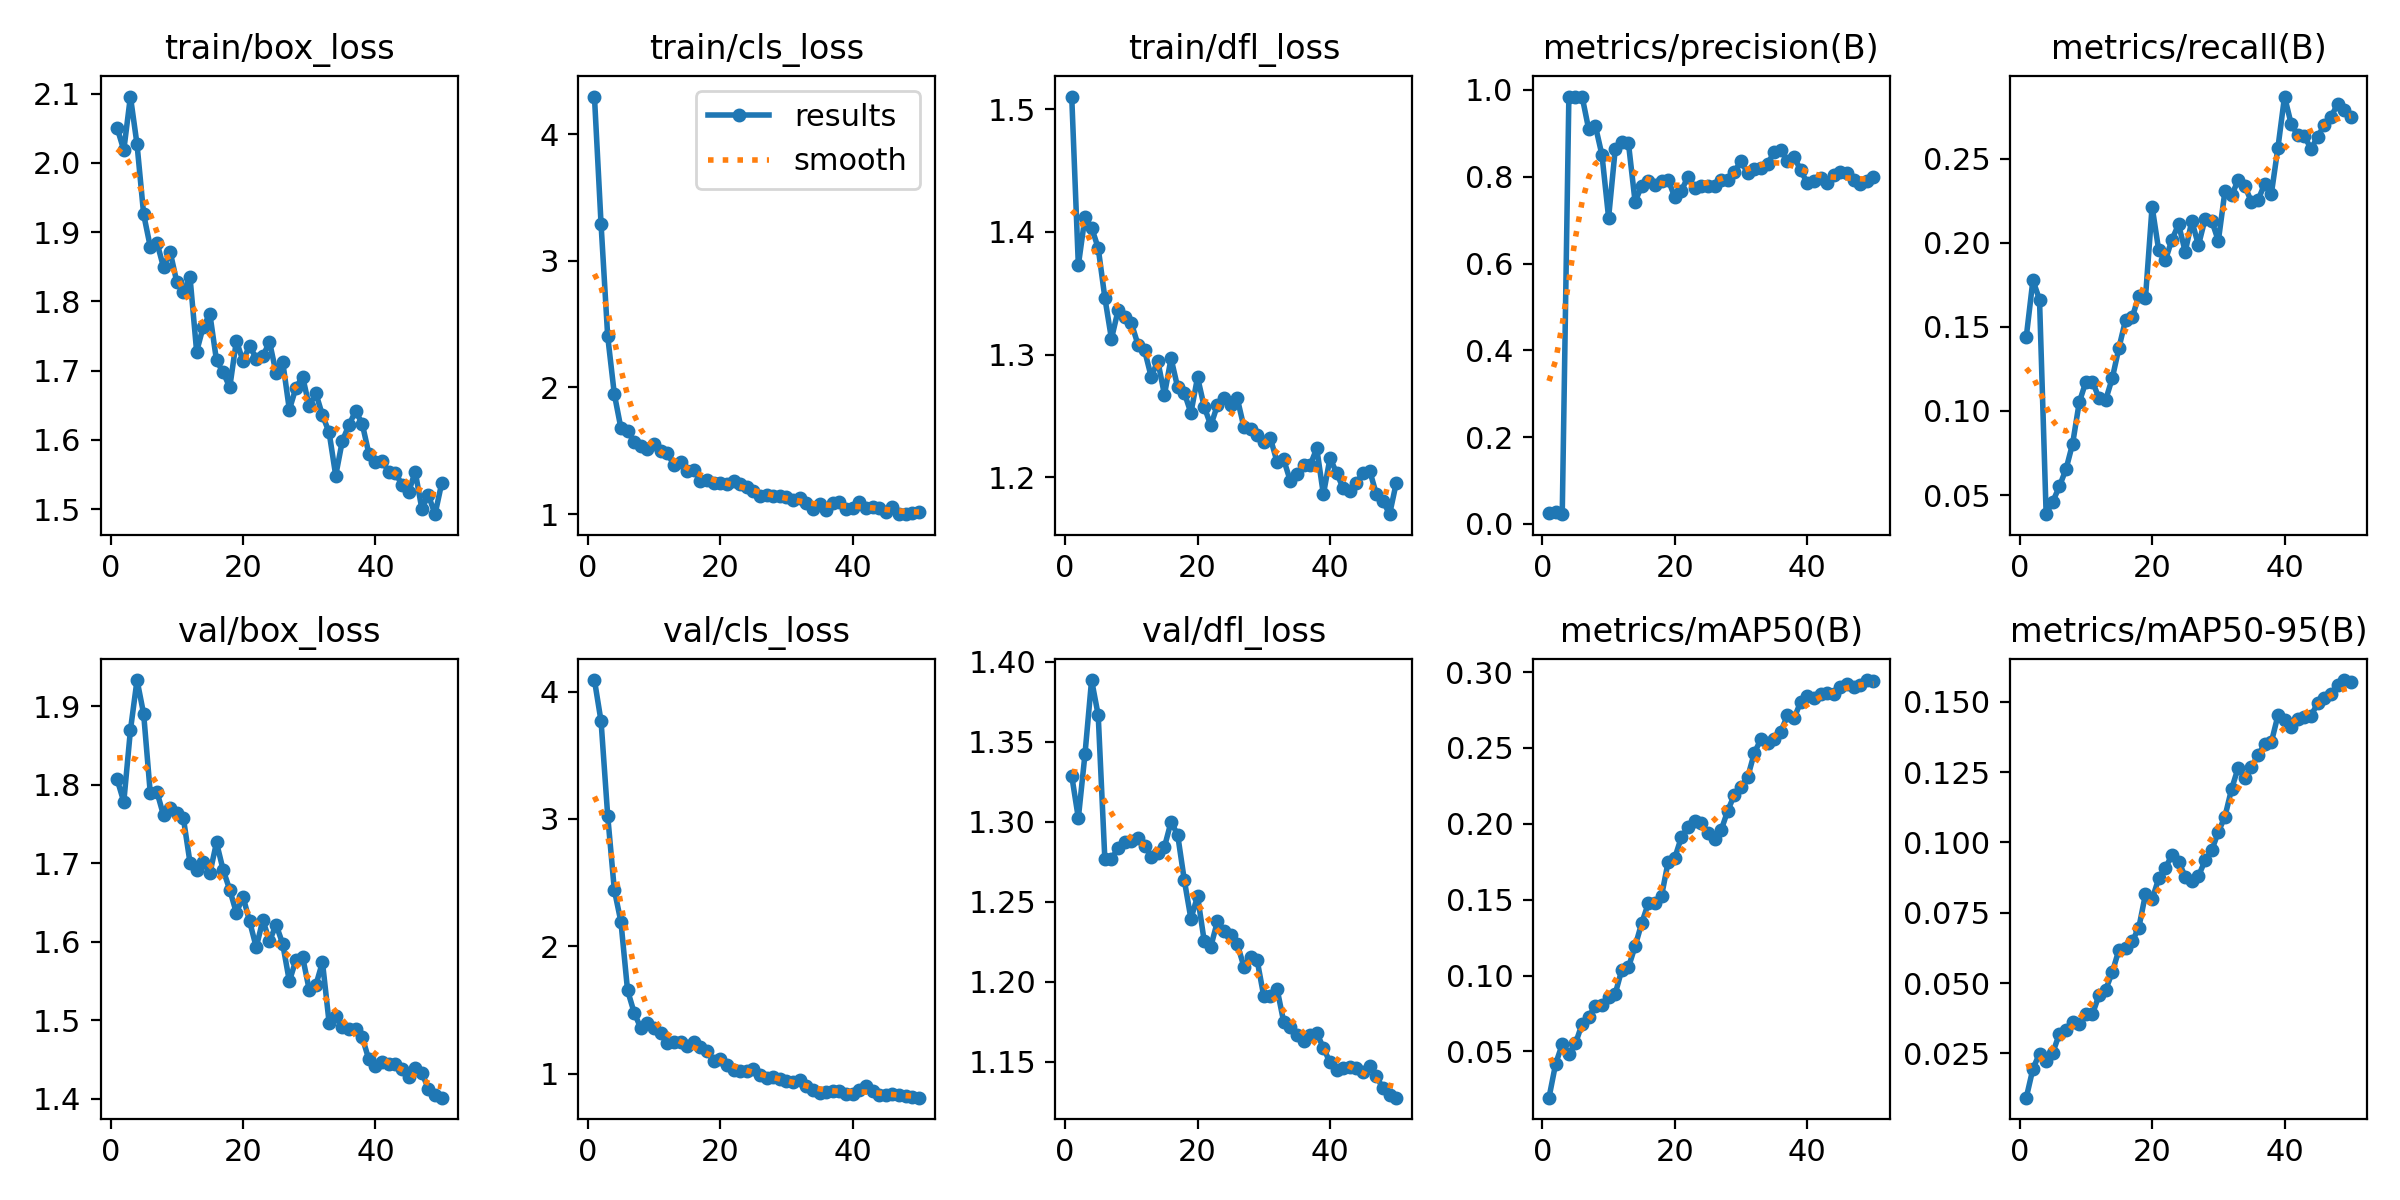


🖼️ Exemples de détections (Validations) :


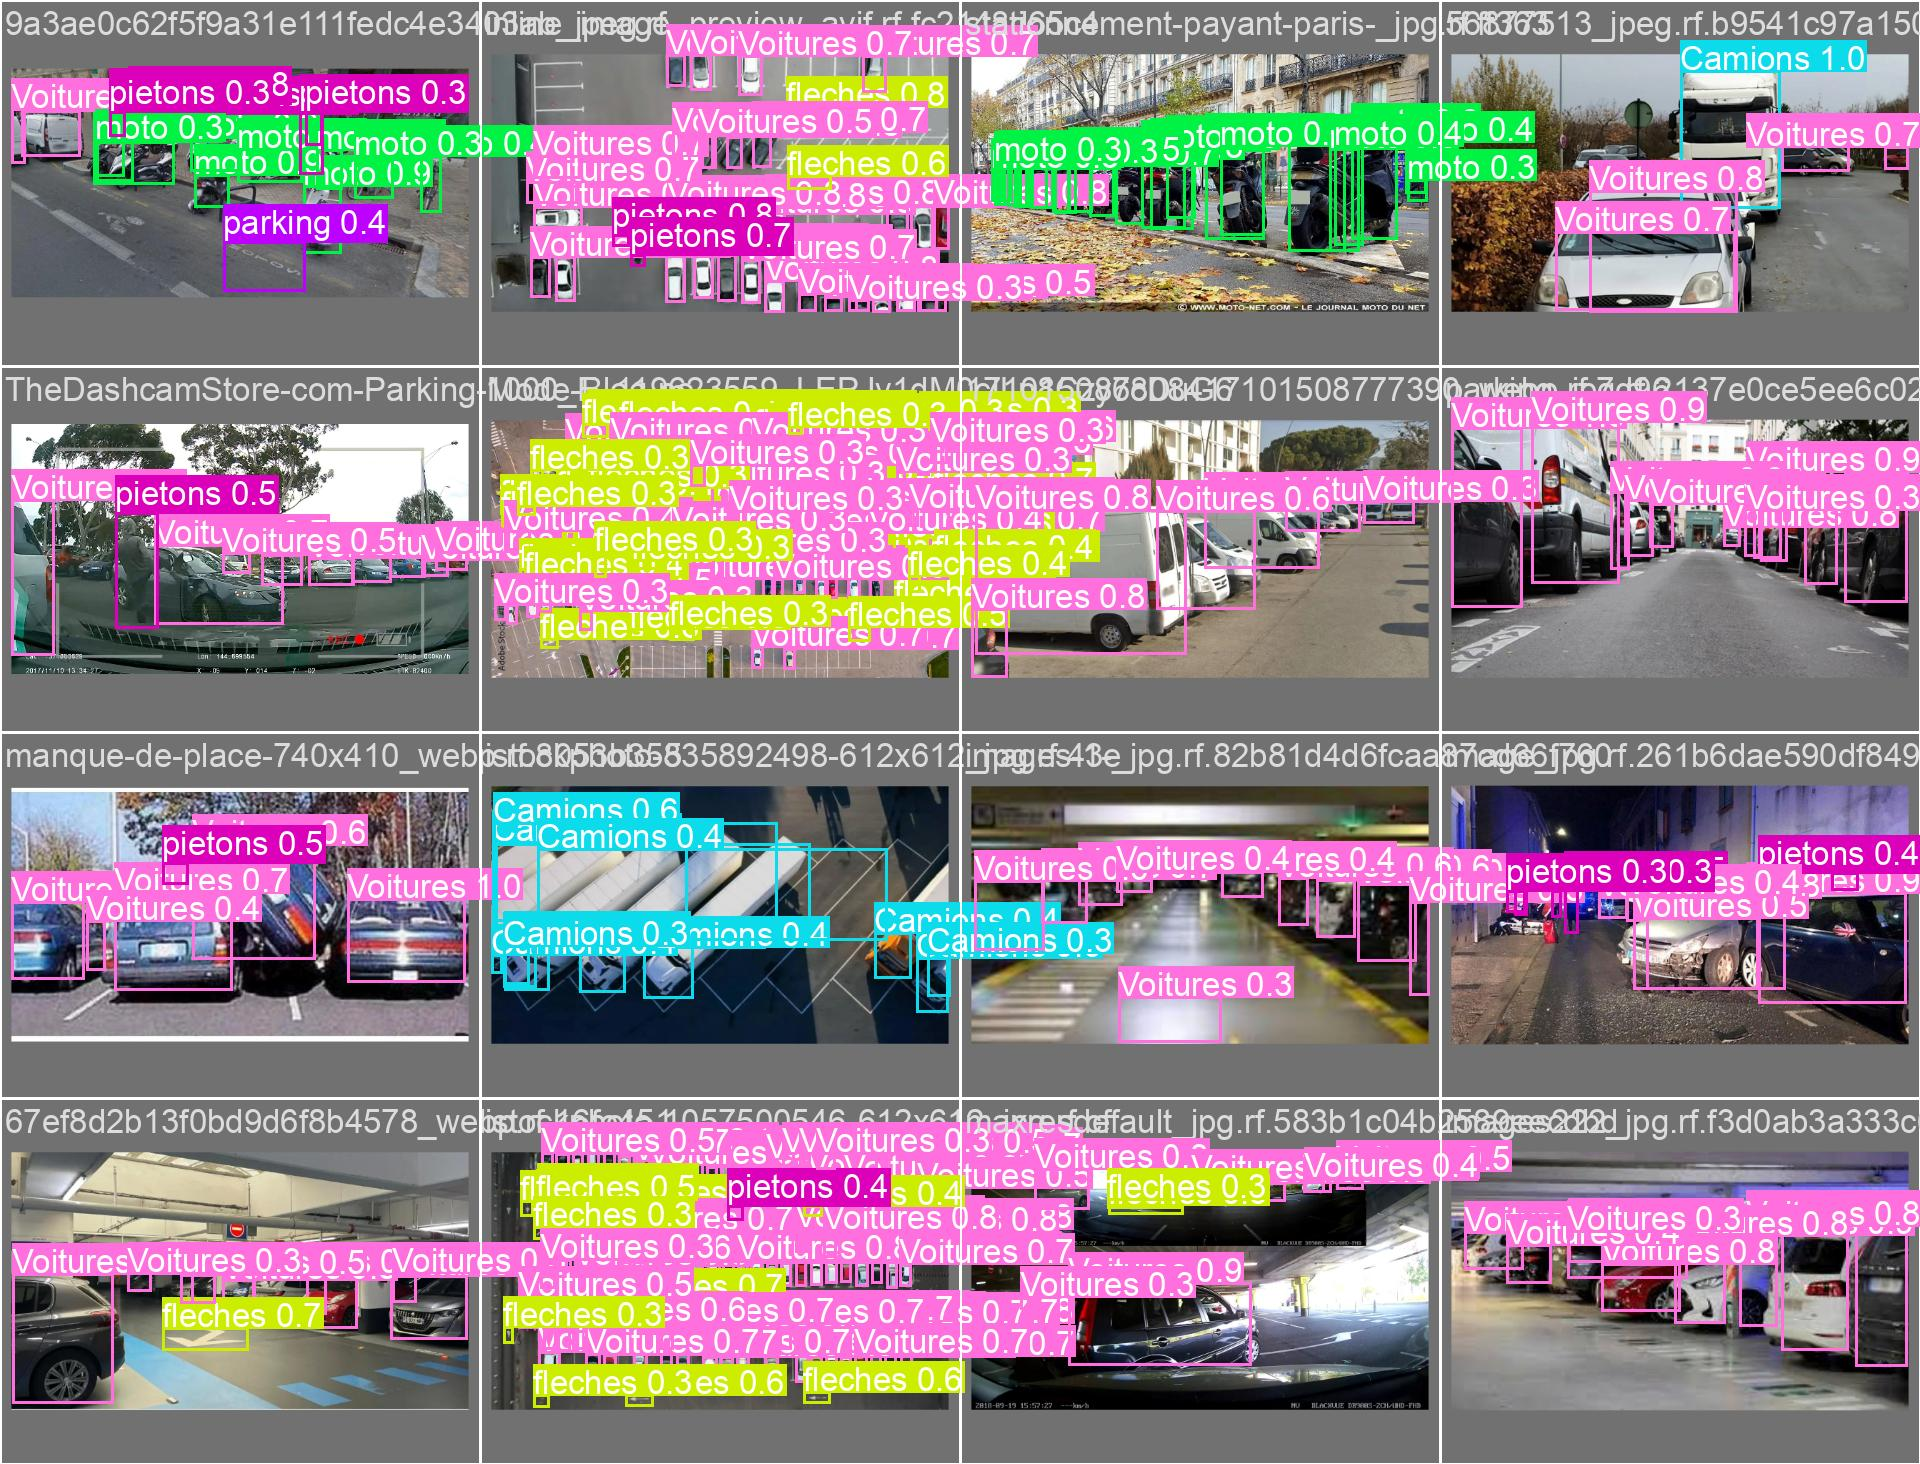



🔵 COMPARAISON FINALE - MODÈLE 2 : YOLOv8 Small (50 Epochs)

📊 Courbes d'apprentissage (mAP, Précision, Rappel) :


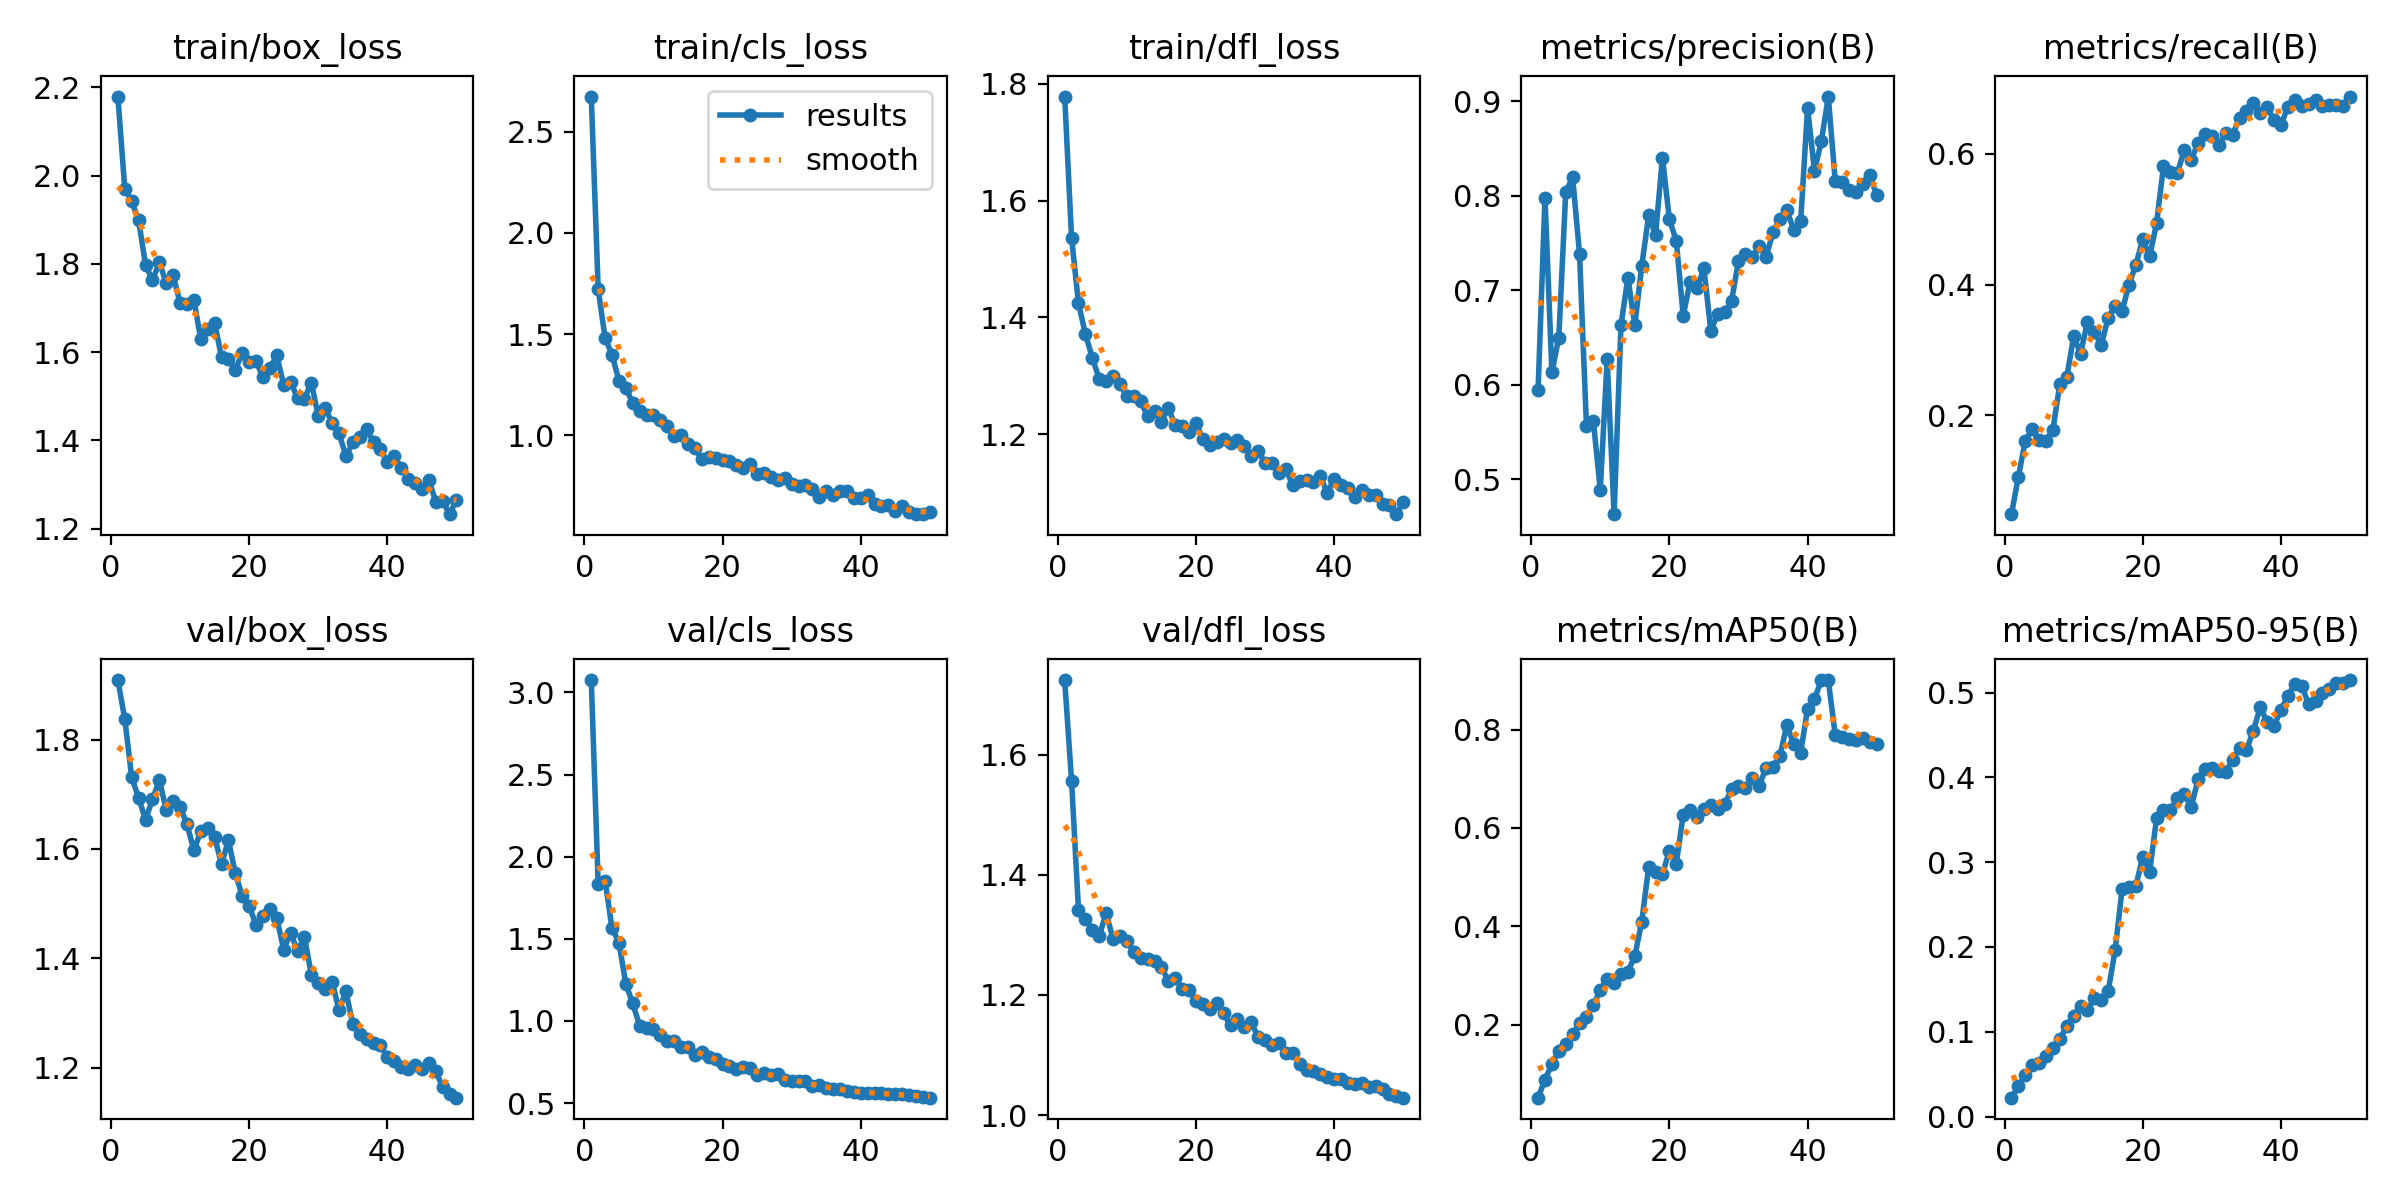


🖼️ Exemples de détections (Validations) :


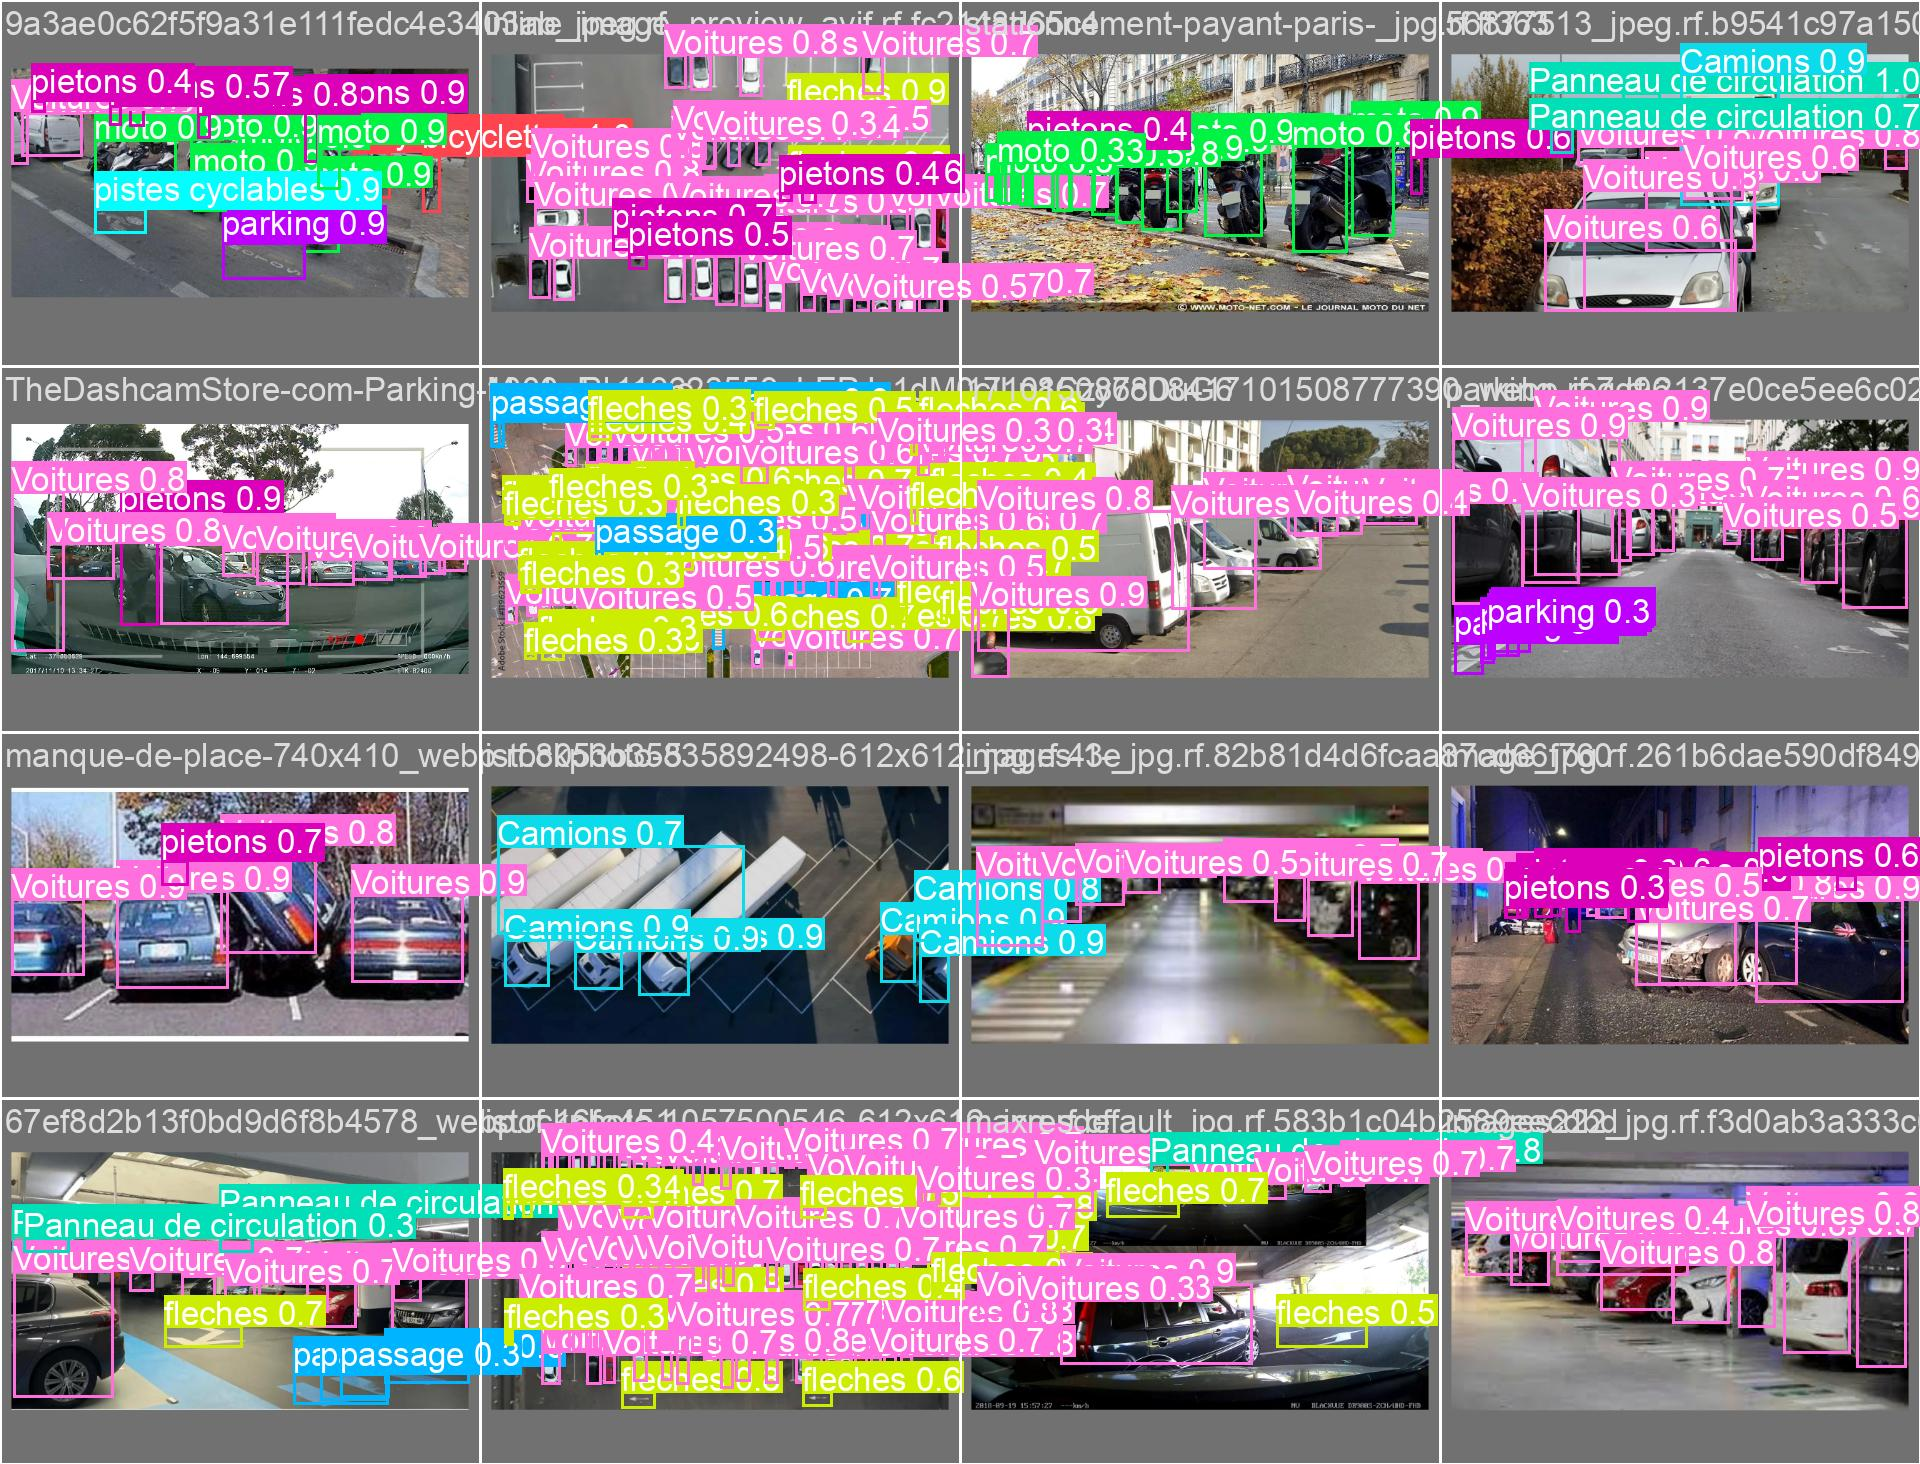

In [10]:
from IPython.display import Image, display
import os

print("===============================================================")
print("🟢 COMPARAISON FINALE - MODÈLE 1 : YOLOv8 Nano (50 Epochs)")
print("===============================================================")
# Note : on utilise yolo_nano_perso2 car c'est le nom dans ton dernier log
chemin_nano_50 = '/content/runs/detect/Projet_IA_Conduite/yolo_nano_perso2'

if os.path.exists(f'{chemin_nano_50}/results.png'):
    print("\n📊 Courbes d'apprentissage (mAP, Précision, Rappel) :")
    display(Image(filename=f'{chemin_nano_50}/results.png', width=800))
    print("\n🖼️ Exemples de détections (Validations) :")
    # On essaye val_batch0_pred ou un autre fichier de validation
    if os.path.exists(f'{chemin_nano_50}/val_batch0_pred.jpg'):
        display(Image(filename=f'{chemin_nano_50}/val_batch0_pred.jpg', width=800))
    else:
        print("Image de validation non trouvée pour le Nano.")
else:
    print("Dossier YOLOv8n (50 epochs) introuvable.")

print("\n\n===============================================================")
print("🔵 COMPARAISON FINALE - MODÈLE 2 : YOLOv8 Small (50 Epochs)")
print("===============================================================")
chemin_small_50 = '/content/runs/detect/Projet_IA_Conduite/yolo_small_50_epochs'

if os.path.exists(f'{chemin_small_50}/results.png'):
    print("\n📊 Courbes d'apprentissage (mAP, Précision, Rappel) :")
    display(Image(filename=f'{chemin_small_50}/results.png', width=800))
    print("\n🖼️ Exemples de détections (Validations) :")
    if os.path.exists(f'{chemin_small_50}/val_batch0_pred.jpg'):
        display(Image(filename=f'{chemin_small_50}/val_batch0_pred.jpg', width=800))
    else:
        print("Image de validation non trouvée pour le Small.")
else:
    print("Dossier YOLOv8s (50 epochs) introuvable.")